# Sine wave

Pedro Mauri Mtz - A01029143

Hecho con seguimiento de la Dr Lizbeth Peralta

In [1]:
"""
Pedro Mauri Mtz - A01029143
Dr Lizbeth Peralta
Fourier: Sine Waves, Filtering and Power Spectral Density
"""

'\nPedro Mauri Mtz - A01029143\nDr Lizbeth Peralta\nFourier: Sine Waves, Filtering and Power Spectral Density\n'

In [2]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

Funciones

In [3]:
# Señal senoidal
# y = A * sin(2 * π * f * t + φ)
def getSineWave(amplitude, frequency, phaseShift, samplingRate, time):
    t = np.linspace(0, time, samplingRate * time, endpoint = False)
    sine_wave = amplitude * np.sin(2 * np.pi * frequency * t + phaseShift)

    return t, sine_wave

In [4]:
# Filtrado de señal (Butterworth)
def filterSignal(order, low, high, sig):
    b, a = signal.butter(order, [low, high], btype = 'band')
    filteredSignal = signal.filtfilt(b, a, sig)

    return filteredSignal

In [5]:
def getPSD(sig):
    [freq, pxx] = signal.welch(sig, fs = 256, nperseg = 256)
    dbHz = [10 * np.log10(i) for i in pxx]

    return freq, dbHz

In [6]:
def plotAmplitude(x, y):
    plt.plot(x, y)
    plt.title('Signal')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (mV)')
    plt.show()

In [7]:
def plotPSD(x, y):
    plt.plot(x, y)
    plt.title('Power Spectral Density')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (dB/Hz)')
    plt.show()

Main

In [8]:
# Parametros iniciales
amplitude = 1 # Micro volts
frequency = 1  # Hertz
phaseShift = 0  # Radianes
samplingRate = 10 # Fs
time = 10 # Segundos

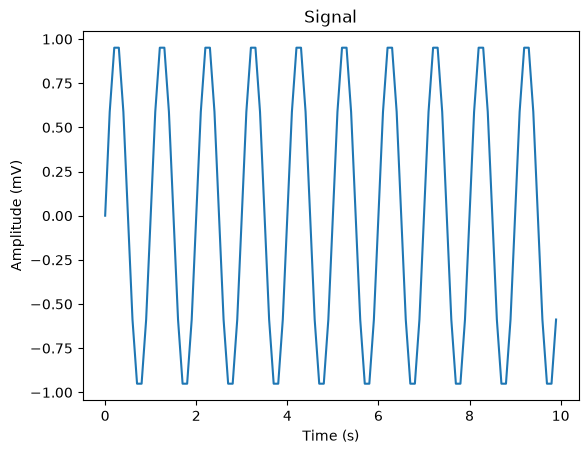

In [9]:
t, sine_wave = getSineWave(amplitude, frequency, phaseShift, samplingRate, time)
plotAmplitude(t, sine_wave)

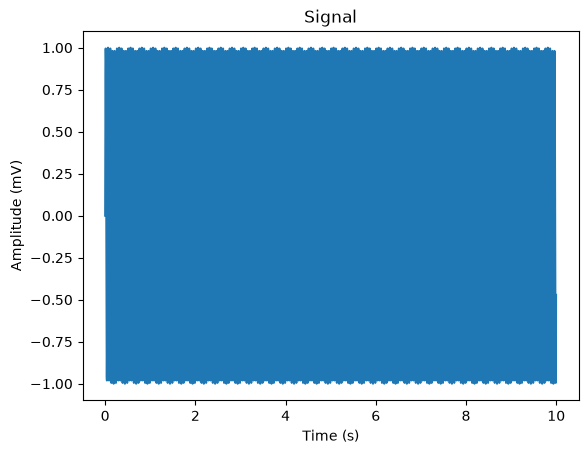

In [10]:
frequency1 = 20
samplingRate1 = 256

t1, sine_wave1 = getSineWave(amplitude, frequency1, phaseShift, samplingRate1, time)
plotAmplitude(t1, sine_wave1)

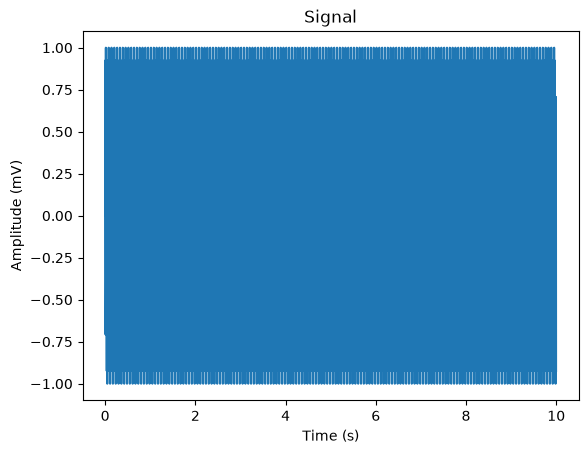

In [11]:
frequency2 = 80

t2, sine_wave2 = getSineWave(amplitude, frequency2, phaseShift, samplingRate1, time)
plotAmplitude(t2, sine_wave2)

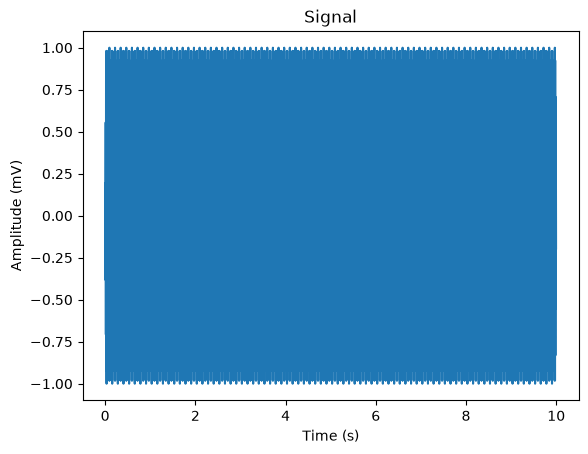

In [12]:
frequency3 = 120

t3, sine_wave3 = getSineWave(amplitude, frequency3, phaseShift, samplingRate1, time)
plotAmplitude(t3, sine_wave3)

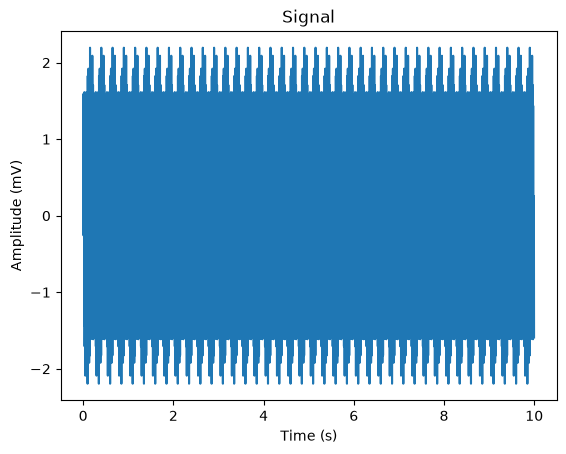

In [13]:
newSignal = sine_wave1 + sine_wave2 + sine_wave3

plotAmplitude(t1, newSignal)

Filtrado de señales

In [14]:
low = 1/256
high = 80/256
clean_signal = filterSignal(4, low, high, newSignal)

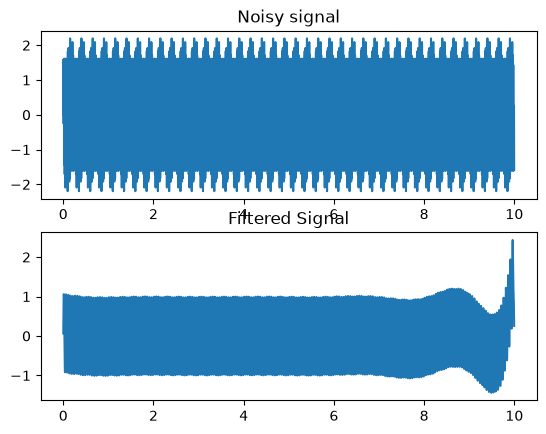

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(t3, newSignal)
ax1.set(title = 'Noisy signal')
ax2.plot(t3, clean_signal)
ax2.set(title = 'Filtered Signal')
plt.show()

PSD

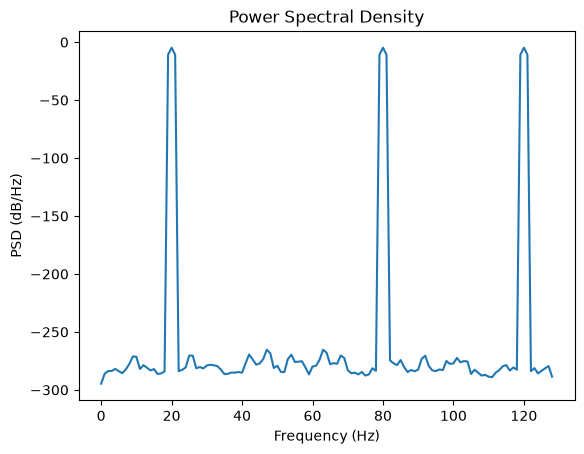

In [16]:
f, psd = getPSD(newSignal)
plotPSD(f, psd)